In [ ]:
!pip install split-folders

In [ ]:
import os
import kagglehub
import splitfolders
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.utils import image_dataset_from_directory
from pathlib import Path
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input, Conv2D, MaxPool2D, Rescaling, Dropout, GlobalAveragePooling2D
from keras.layers import RandomZoom, RandomRotation, RandomFlip, RandomBrightness, RandomContrast, RandomSaturation

# Brain Cancer Classification

In [ ]:

download_path = kagglehub.dataset_download("orvile/brain-cancer-mri-dataset")
print("Download path:", download_path)

for root, dirs, files in os.walk(download_path):
    if set(["brain_glioma", "brain_menin", "brain_tumor"]).issubset(set(dirs)):
        source_path = root
        break

print("Source path trovato:", source_path)
print("Classi:", os.listdir(source_path))

output_folder = "/content/Brain_Cancer_Split"

# Cancella eventuale split precedente
import shutil
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

splitfolders.ratio(
    source_path,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

print("Dataset salvato in:", output_folder)
for root, dirs, files in os.walk(output_folder):
    image_files = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if image_files:
        print(root, len(image_files))

Using Colab cache for faster access to the 'brain-cancer-mri-dataset' dataset.
Download path: /kaggle/input/brain-cancer-mri-dataset
Source path trovato: /kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer
Classi: ['brain_tumor', 'brain_glioma', 'brain_menin']


Copying files: 6056 files [00:09, 616.90 files/s] 

Dataset salvato in: /content/Brain_Cancer_Split
/content/Brain_Cancer_Split/val/brain_menin 300
/content/Brain_Cancer_Split/val/brain_tumor 307
/content/Brain_Cancer_Split/val/brain_glioma 300
/content/Brain_Cancer_Split/test/brain_menin 302
/content/Brain_Cancer_Split/test/brain_tumor 308
/content/Brain_Cancer_Split/test/brain_glioma 302
/content/Brain_Cancer_Split/train/brain_menin 1402
/content/Brain_Cancer_Split/train/brain_tumor 1433
/content/Brain_Cancer_Split/train/brain_glioma 1402


In [ ]:
train_set = '/content/Brain_Cancer_Split/train'
test_set = '/content/Brain_Cancer_Split/test'
val_set = '/content/Brain_Cancer_Split/val'

In [ ]:
img_size = (200,200)
batch_size = 32

In [ ]:
train_ds = image_dataset_from_directory(
    train_set,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_set,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42

)

val_ds = image_dataset_from_directory(
    val_set,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    seed=42
)

Found 4237 files belonging to 3 classes.
Found 912 files belonging to 3 classes.
Found 907 files belonging to 3 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)

print('Classi:',class_names)
print('Numero di classi:',num_classes)

Classi: ['brain_glioma', 'brain_menin', 'brain_tumor']
Numero di classi: 3


#Costruzione Rete Neurale Convoluzionale

In [ ]:
# data_augmentation = Sequential(
#     layers=[
#         RandomFlip('horizontal'),
#         RandomRotation(0.2),
#         RandomZoom(0.2),
#         RandomBrightness(0.2),
#         RandomContrast(0.2),
#         RandomSaturation(0.2)
#     ]
# ) # modello alternativo con Xception

In [ ]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.10),
    RandomZoom(0.1),
    RandomContrast(0.1)
]) #modello Densenet121

In [ ]:
preprocess_input = tf.keras.applications.densenet.preprocess_input

IMG_SHAPE = img_size + (3,)

backbone = tf.keras.applications.DenseNet121(
     input_shape=IMG_SHAPE,
     include_top=False,
     weights="imagenet",
 )

In [ ]:
backbone.trainable = False

In [ ]:
classification_heads = Sequential(
    layers=[
        GlobalAveragePooling2D(),
        Dense(units=256, activation='relu'),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
    ]
)

In [ ]:
inputs = Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = backbone(x)
x = classification_heads(x)

transfer_learning_model = keras.Model(inputs=inputs, outputs=x)

In [ ]:
learning_rate = 0.0001
transfer_learning_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
transfer_learning_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_10 (TrueDivide)     │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_5 (Add)                     │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_11 (TrueDivide)     │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 6, 6, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 3)              │       263,171 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

history = transfer_learning_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 46s 197ms/step - accuracy: 0.5926 - loss: 0.9490 - val_accuracy: 0.8501 - val_loss: 0.4408 - learning_rate: 1.0000e-04
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.7845 - loss: 0.5266 - val_accuracy: 0.8567 - val_loss: 0.3787 - learning_rate: 1.0000e-04
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.8305 - loss: 0.4376 - val_accuracy: 0.8523 - val_loss: 0.3492 - learning_rate: 1.0000e-04
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - accuracy: 0.8468 - loss: 0.3883 - val_accuracy: 0.8699 - val_loss: 0.3145 - learning_rate: 1.0000e-04
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.8617 - loss: 0.3607 - val_accuracy: 0.8589 - val_loss: 0.3319 - learning_rate: 1.0000e-04
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - accuracy: 0.8685 - loss: 0.3395 - val_accuracy: 0.8853 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 15

In [ ]:
test_loss, test_accuracy = transfer_learning_model.evaluate(test_ds)

print(f'test loss: {test_loss}')
print(f'test_accuracy: {test_accuracy}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.8794 - loss: 0.3143
test loss: 0.3142605721950531
test_accuracy: 0.8793859481811523


# Dati modello più performante
- accuracy: 0.9068
- loss: 0.2235
- test loss: 0.22346140444278717
- test_accuracy: 0.906798243522644

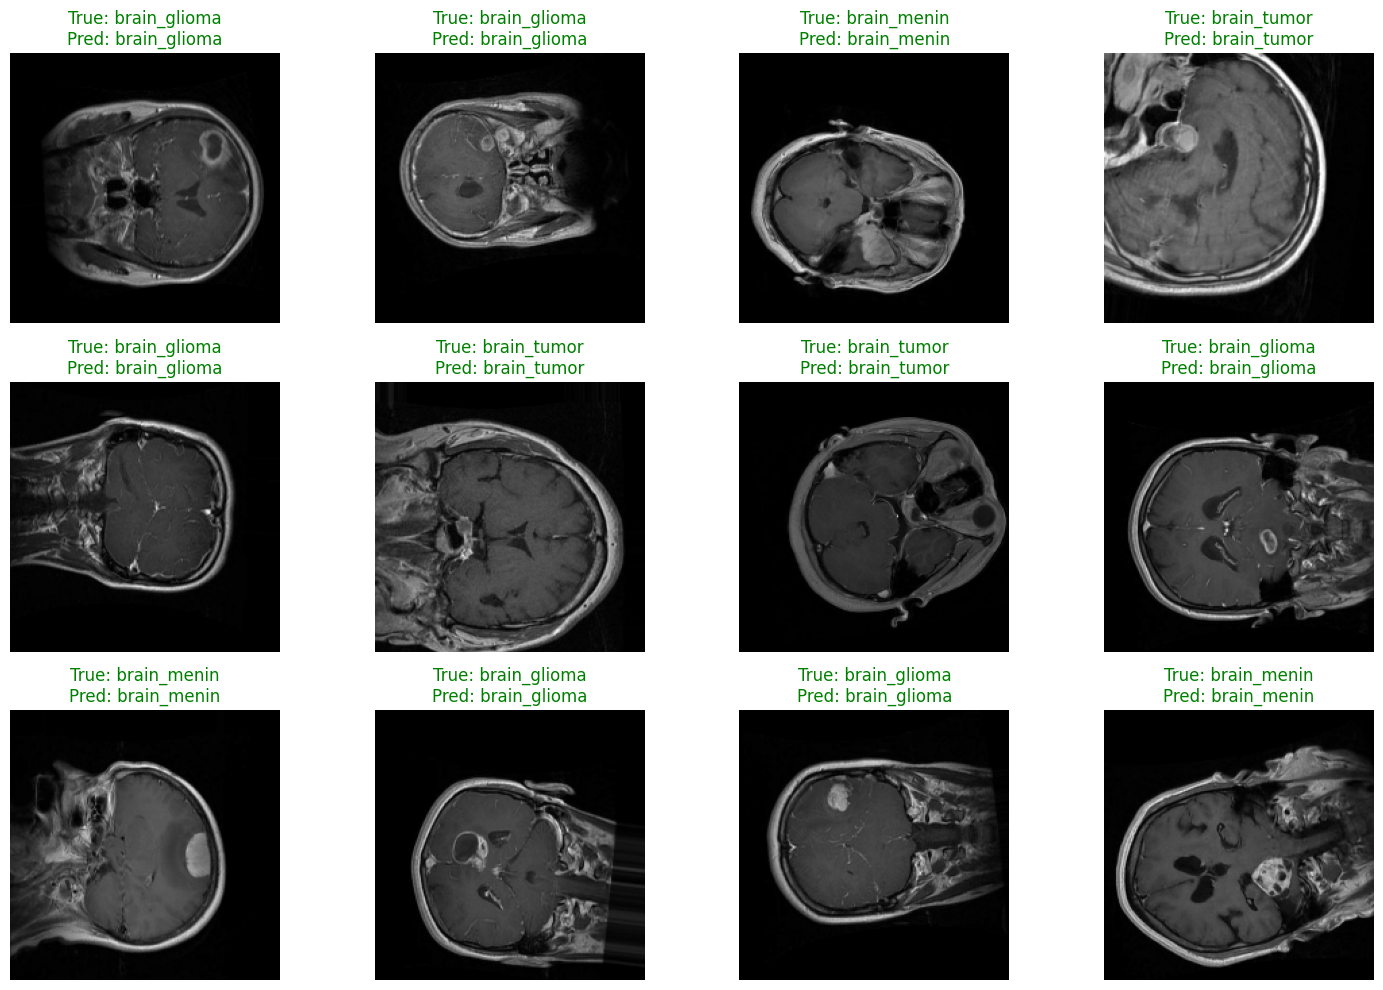

In [ ]:
class_names = test_ds.class_names

all_images = []
all_labels = []

for images, labels in test_ds:
    for img, label in zip(images, labels):
        all_images.append(img)
        all_labels.append(int(label.numpy()))

n_samples = 12
random_indices = np.random.choice(
    len(all_images),
    size=min(n_samples, len(all_images)),
    replace=False
)

plt.figure(figsize=(15, 10))

for plot_idx, idx in enumerate(random_indices, start=1):

    img = all_images[idx]
    true_label = all_labels[idx]

    prediction = transfer_learning_model.predict(
        np.expand_dims(img.numpy(), axis=0),
        verbose=0
    )

    pred_label = int(np.argmax(prediction, axis=1)[0])

    correct = true_label == pred_label

    plt.subplot(3, 4, plot_idx)
    plt.imshow(img.numpy().astype("uint8"))

    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]}",
        color="green" if correct else "red"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

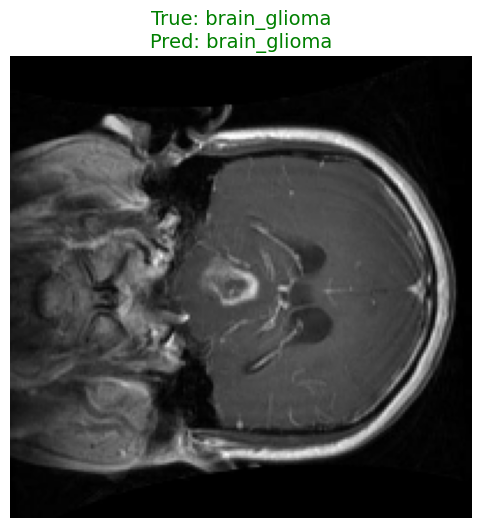

In [ ]:
class_names = test_ds.class_names

all_images = []
all_labels = []

for images, labels in test_ds:
    all_images.extend(images)
    all_labels.extend(labels.numpy())

idx = np.random.randint(len(all_images))

image = all_images[idx]
true_label = int(all_labels[idx])

prediction = transfer_learning_model.predict(
    np.expand_dims(image.numpy(), axis=0),
    verbose=0
)

pred_label = int(np.argmax(prediction, axis=1)[0])

plt.figure(figsize=(6, 6))
plt.imshow(image.numpy().astype("uint8"))

plt.title(
    f"True: {class_names[true_label]}\n"
    f"Pred: {class_names[pred_label]}",
    color="green" if true_label == pred_label else "red",
    fontsize=14
)

plt.axis("off")
plt.show()